In [136]:
# importa a biblioteca pandas e dá o apelido 'pd'
import pandas as pd  

# importa a biblioteca numpy e dá o apelido 'np'
import numpy as np 

In [137]:
Delegacias = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv',sep=';',encoding='latin1')
Delegacias


,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36624,159,8,2025,2025m08,35,4,Cachoeiras de Macacu,3300803,Interior,1,...,5.0,0.0,16,0,0,0,0,0,148,2
36625,165,8,2025,2025m08,33,5,Mangaratiba,3302601,Interior,0,...,5.0,0.0,21,2,0,0,0,0,179,2
36626,166,8,2025,2025m08,33,5,Angra dos Reis,3300100,Interior,3,...,11.0,3.0,63,8,0,0,0,0,595,2
36627,167,8,2025,2025m08,43,5,Paraty,3303807,Interior,0,...,3.0,0.0,13,2,0,1,0,0,234,2


In [138]:
municipios_rj = [
    "Rio de Janeiro",
    "Belford Roxo",
    "Duque de Caxias",
    "Guapimirim",
    "Itaboraí",
    "Itaguaí",
    "Japeri",
    "Magé",
    "Maricá",
    "Mesquita",
    "Nilópolis",
    "Niterói",
    "Nova Iguaçu",
    "Paracambi",
    "Queimados",
    "São Gonçalo",
    "São João de Meriti",
    "Seropédica",
    "Tanguá",
    "Cachoeiras de Macacu",
    "Rio Bonito",
    "Petrópolis"
]


#04 Compare os outliers dos dois primeiros anos da atual gestão
com os dois primeiros anos da gestão anterior no que diz
respeito a estelionato na região metropolitana. O padrão de

manteve?

Alguma delegacia deixou de ser outlier? Alguma delegacia
passou a ser considerada outlier que anteriormente não era ?

In [140]:
gestao_Anterior = Delegacias[(Delegacias['munic'].isin(municipios_rj)) & (Delegacias['ano'].isin([2019, 2020]))]
gestao_Anterior

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
25669,1,1,2019,2019m01,5,1,Rio de Janeiro,3304557,Capital,0,...,8.0,1.0,11,1,0,0,0,0,572,3
25670,4,1,2019,2019m01,5,1,Rio de Janeiro,3304557,Capital,1,...,15.0,10.0,12,2,1,0,0,0,625,3
25671,5,1,2019,2019m01,5,1,Rio de Janeiro,3304557,Capital,0,...,30.0,18.0,29,3,0,0,0,0,1095,3
25672,6,1,2019,2019m01,4,1,Rio de Janeiro,3304557,Capital,3,...,9.0,2.0,33,3,0,0,0,0,575,3
25673,7,1,2019,2019m01,5,1,Rio de Janeiro,3304557,Capital,1,...,0.0,0.0,9,0,0,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28891,82,12,2020,2020m12,12,4,Maricá,3302700,Grande NiterÃ³i,10,...,7.0,0.0,49,8,0,0,0,0,537,3
28907,105,12,2020,2020m12,26,7,Petrópolis,3303906,Interior,3,...,37.0,0.0,75,1,1,0,0,0,510,3
28908,106,12,2020,2020m12,26,7,Petrópolis,3303906,Interior,1,...,7.0,0.0,18,0,0,0,0,0,166,3
28916,119,12,2020,2020m12,35,4,Rio Bonito,3304300,Interior,0,...,5.0,1.0,17,1,0,0,0,0,124,3


In [141]:


gestao_atual_Agrupamento = gestao_atual.groupby(['cisp'])['estelionato'].sum().reset_index()
gestao_atual_Agrupamento


,cisp,estelionato
0,1,2146
1,4,1010
2,5,3011
3,6,1527
4,7,753
...,...,...
71,82,3498
72,105,3310
73,106,1466
74,119,501


In [142]:
gestao_Anterior_grupamento = gestao_Anterior.groupby(['cisp'])['estelionato'].sum().reset_index()
gestao_Anterior_grupamento

,cisp,estelionato
0,1,2560
1,4,417
2,5,1788
3,6,706
4,7,114
...,...,...
71,82,684
72,105,1083
73,106,223
74,119,124


#                                                    Resumo da Análise de Outliers — Estelionato



In [143]:


array_gestao_atual_grupamento = np.array(gestao_atual_Agrupamento["estelionato"])

# Mediana (valor central)
mediana_atual = np.median(array_gestao_atual_grupamento)
media_atual = np.mean(array_gestao_atual_grupamento)

# Quartis
q1_atual = np.percentile(array_gestao_atual_grupamento, 25)  # Primeiro quartil
q2_atual = np.percentile(array_gestao_atual_grupamento, 50)  # Terceiro quartil
q3_atual = np.percentile(array_gestao_atual_grupamento, 75)  # Terceiro quartil
distancia_atual = (media_atual - mediana_atual) / mediana_atual
iqr_atual = q3_atual - q1_atual
limite_superior_atual = q3_atual + (1.5*iqr_atual)
limite_inferior_atual = q1_atual - (1.5*iqr_atual)

print(f'media {media_atual}')
print(f'mediana {mediana_atual}')
print(f'distancia {distancia_atual*100}%')

media 2776.9605263157896
mediana 2251.0
distancia 23.365638663517974%


In [144]:
array_gestao_anterior_grupamento = np.array(gestao_Anterior_grupamento["estelionato"])

# Mediana (valor central)
mediana_anterior = np.median(array_gestao_anterior_grupamento)
media_anterior = np.mean(array_gestao_anterior_grupamento)

# Quartis
q1_anterior = np.percentile(array_gestao_anterior_grupamento, 25)  # Primeiro quartil
q2_anterior = np.percentile(array_gestao_anterior_grupamento, 50)  # Terceiro quartil
q3_anterior = np.percentile(array_gestao_anterior_grupamento, 75)  # Terceiro quartil
distancia_anterior = (media_anterior - mediana_anterior) / mediana_anterior
iqr_anterior = q3_anterior - q1_anterior
limite_superior_anterior = q3_anterior + (1.5*iqr_anterior)
limite_inferior_anterior = q1_anterior - (1.5*iqr_anterior)

print(f'media {media_anterior}')
print(f'mediana {mediana_anterior}')
print(f'distancia {distancia_anterior*100}%')

media 987.3815789473684
mediana 706.5
distancia 39.75676984393042%


| Tipos                                  | Gestão Anterior | Gestão Atual |
| ------------------------------------------ | --------------- | ------------ |
| Média                                      | **2.776,96**    | **987,38**   |
| Mediana                                    | **2.251,00**    | **706,50**   |
| Distância percentual entre média e mediana | **23,37%**      | **39,76%**   |





In [ ]:

Outliers_atual = gestao_atual_Agrupamento.loc[gestao_atual_Agrupamento['estelionato'] >= limite_superior_atual]
Outliers_atual.sort_values(by='estelionato', ascending= False)





,cisp,estelionato
31,35,10026
12,16,9665
28,32,9529
38,42,6433


In [146]:

Outliers_Anterior = gestao_Anterior_grupamento.loc[gestao_Anterior_grupamento['estelionato'] >= limite_superior_anterior]
Outliers_Anterior.sort_values(by='estelionato', ascending= False)



,cisp,estelionato
31,35,3592
12,16,3054


| CISP | Estelionato (Atual) | Estelionato (Anterior) | Diferença Absoluta | Variação (%) |
| ---- | ------------------- | ---------------------- | ------------------ | ------------ |
| 31   | 10.026              | 3.592                  | +6.434             | +179%        |
| 12   | 9.665               | 3.054                  | +6.611             | +216%        |
| 28   | 9.529               | —                      | —                  | —            |
| 38   | 6.433               | —                      | —                  | —            |


In [147]:
import pandas as pd

import matplotlib.pyplot as plt

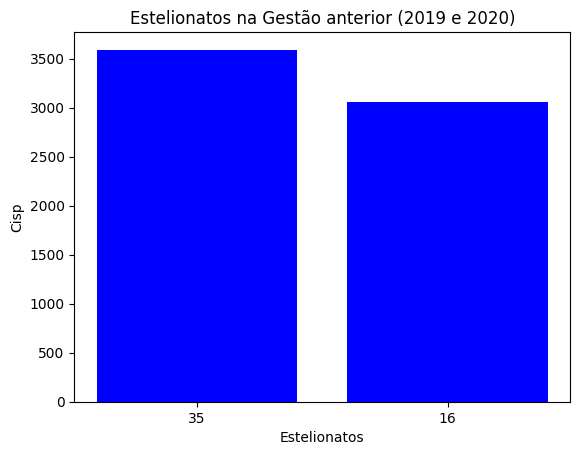

In [148]:



Outliers_Anterior = Outliers_Anterior.sort_values(by='estelionato', ascending= False)

Outliers_Anterior['cisp'] = Outliers_Anterior['cisp'].astype(str)

plt.bar(Outliers_Anterior['cisp'], Outliers_Anterior['estelionato'], color='blue')

plt.title('Estelionatos na Gestão anterior (2019 e 2020)')

# Define o rótulo do eixo X
plt.xlabel('Estelionatos')

# Define o rótulo do eixo Y
plt.ylabel('Cisp')

# Exibe o gráfico na tela
plt.show()

In [149]:
Outliers_Anterior['cisp'].dtype

dtype('O')

In [150]:

Outliers_Anterior = gestao_Anterior_grupamento.loc[gestao_Anterior_grupamento['estelionato'] >= limite_superior_anterior]
Outliers_Anterior.sort_values(by='estelionato', ascending= False)

,cisp,estelionato
31,35,3592
12,16,3054


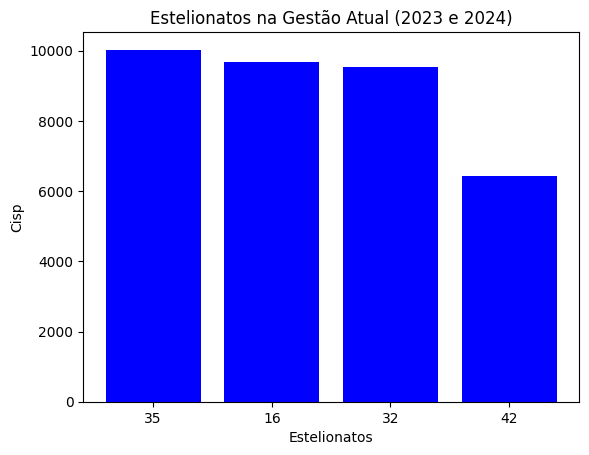

In [151]:



Outliers_atual = Outliers_atual.sort_values(by='estelionato', ascending= False)

Outliers_atual ['cisp'] = Outliers_atual['cisp']. astype(str)

plt.bar(Outliers_atual['cisp'], Outliers_atual['estelionato'], color='blue')

plt.title('Estelionatos na Gestão Atual (2023 e 2024)')

# Define o rótulo do eixo X
plt.xlabel('Estelionatos')

# Define o rótulo do eixo Y
plt.ylabel('Cisp')

# Exibe o gráfico na tela
plt.show()

| CISP | Gestão Anterior (2019–2020) | Gestão Atual (2023–2024) | Variação | Situação           |
| ---- | --------------------------- | ------------------------ | -------- | ------------------ |
| 35   | 3.592                       | 10.026                   | 🔺 +179% | Permaneceu outlier |
| 16   | 3.054                       | 9.665                    | 🔺 +216% | Permaneceu outlier |
| 32   | –                           | 9.529                    | 🔺 –     | Novo outlier       |
| 42   | –                           | 6.433                    | 🔺 –     | Novo outlier       |


C:\Users\jose.flor\AppData\Local\Temp\ipykernel_34436\4285886600.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Outliers_Anterior['cisp'] = Outliers_Anterior['cisp'].astype(str)


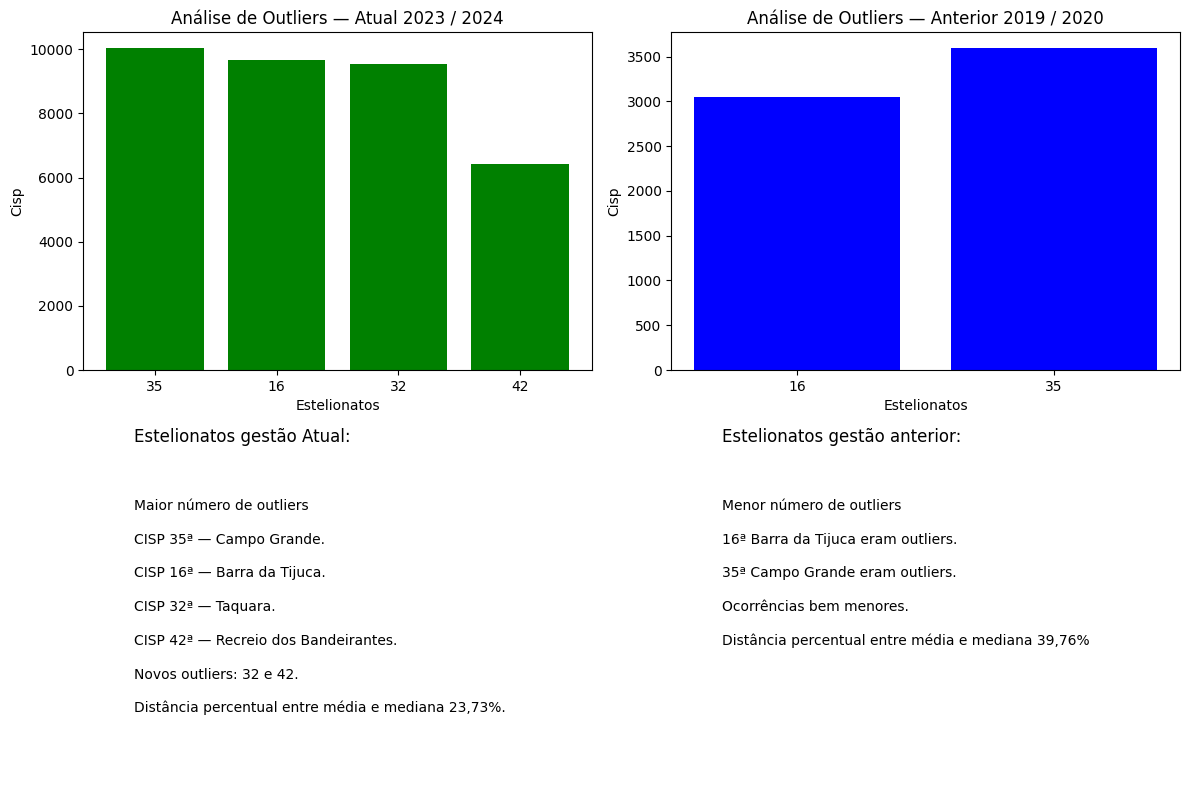

In [164]:

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

#Gráfio 1
axs[0, 0].bar(Outliers_atual ['cisp'], Outliers_atual['estelionato'],  color='green')

axs[0, 0].set_title  ('Análise de Outliers — Atual 2023 / 2024')
axs[0, 0].set_xlabel ('Estelionatos'  )
axs[0, 0].set_ylabel ('Cisp'  )


#Gráfio 2
Outliers_Anterior['cisp'] = Outliers_Anterior['cisp'].astype(str)
axs[0, 1].bar(Outliers_Anterior['cisp'], Outliers_Anterior['estelionato'], color='blue')

axs[0, 1].set_title  ('Análise de Outliers — Anterior 2019 / 2020')
axs[0, 1].set_xlabel ('Estelionatos'  )
axs[0, 1].set_ylabel ('Cisp'  )

#texto 1

axs[1, 0].axis('off')

axs[1, 0].text(0.1, 1, 'Estelionatos gestão Atual:', fontsize=12)

axs[1, 0].text(0.1, 0.8, 'Maior número de outliers ', fontsize=10)

axs[1, 0].text(0.1, 0.7, 'CISP 35ª — Campo Grande.', fontsize=10)

axs[1, 0].text(0.1, 0.6, 'CISP 16ª — Barra da Tijuca.', fontsize=10)

axs[1, 0].text(0.1, 0.5, 'CISP 32ª — Taquara.', fontsize=10)

axs[1, 0].text(0.1, 0.4, 'CISP 42ª — Recreio dos Bandeirantes.', fontsize=10)

axs[1, 0].text(0.1, 0.3, 'Novos outliers: 32 e 42.', fontsize=10)

axs[1, 0].text(0.1, 0.2, 'Distância percentual entre média e mediana 23,73%.', fontsize=10)

#texto 2

axs[1, 1].axis('off')

axs[1, 1] .text(0.1, 1, 'Estelionatos gestão anterior: ', fontsize=12 , color='black' )

axs[1, 1].text(0.1, 0.8, 'Menor número de outliers', fontsize=10)

axs[1, 1].text(0.1, 0.7, '16ª Barra da Tijuca eram outliers.', fontsize=10)

axs[1, 1].text(0.1, 0.6, '35ª Campo Grande eram outliers.', fontsize=10)

axs[1, 1].text(0.1, 0.5, 'Ocorrências bem menores.', fontsize=10)

axs[1, 1].text(0.1, 0.4, 'Distância percentual entre média e mediana 39,76%', fontsize=10)



plt. tight_layout()



C:\Users\jose.flor\AppData\Local\Temp\ipykernel_34436\4285886600.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Outliers_Anterior['cisp'] = Outliers_Anterior['cisp'].astype(str)


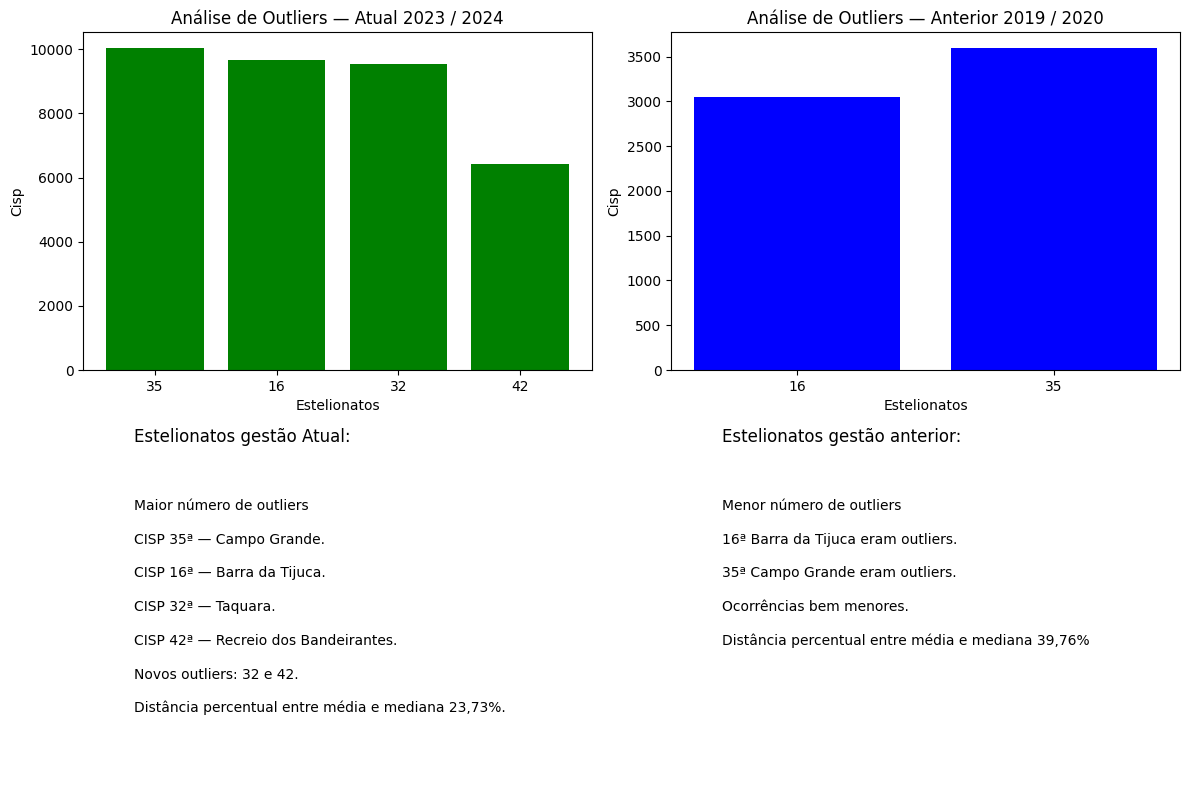

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

#Gráfio 1
axs[0, 0].bar(Outliers_atual ['cisp'], Outliers_atual['estelionato'],  color='green')

axs[0, 0].set_title  ('Análise de Outliers — Atual 2023 / 2024')
axs[0, 0].set_xlabel ('Estelionatos'  )
axs[0, 0].set_ylabel ('Cisp'  )


#Gráfio 2
Outliers_Anterior['cisp'] = Outliers_Anterior['cisp'].astype(str)
axs[0, 1].bar(Outliers_Anterior['cisp'], Outliers_Anterior['estelionato'], color='blue')

axs[0, 1].set_title  ('Análise de Outliers — Anterior 2019 / 2020')
axs[0, 1].set_xlabel ('Estelionatos'  )
axs[0, 1].set_ylabel ('Cisp'  )

#texto 1

axs[1, 0].axis('off')

axs[1, 0].text(0.1, 1, 'Estelionatos gestão Atual:', fontsize=12)

axs[1, 0].text(0.1, 0.8, 'Maior número de outliers ', fontsize=10)

axs[1, 0].text(0.1, 0.7, 'CISP 35ª — Campo Grande.', fontsize=10)

axs[1, 0].text(0.1, 0.6, 'CISP 16ª — Barra da Tijuca.', fontsize=10)

axs[1, 0].text(0.1, 0.5, 'CISP 32ª — Taquara.', fontsize=10)

axs[1, 0].text(0.1, 0.4, 'CISP 42ª — Recreio dos Bandeirantes.', fontsize=10)

axs[1, 0].text(0.1, 0.3, 'Novos outliers: 32 e 42.', fontsize=10)

axs[1, 0].text(0.1, 0.2, 'Distância percentual entre média e mediana 23,73%.', fontsize=10)

#texto 2

axs[1, 1].axis('off')

axs[1, 1] .text(0.1, 1, 'Estelionatos gestão anterior: ', fontsize=12 , color='black' )

axs[1, 1].text(0.1, 0.8, 'Menor número de outliers', fontsize=10)

axs[1, 1].text(0.1, 0.7, '16ª Barra da Tijuca eram outliers.', fontsize=10)

axs[1, 1].text(0.1, 0.6, '35ª Campo Grande eram outliers.', fontsize=10)

axs[1, 1].text(0.1, 0.5, 'Ocorrências bem menores.', fontsize=10)

axs[1, 1].text(0.1, 0.4, 'Distância percentual entre média e mediana 39,76%', fontsize=10)



plt. tight_layout()

# puxar as médias 